In [1]:
# import necessary libries for the project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load and inspect dataset.
df = pd.read_csv(r"C:\Users\LUPHEN\Documents\NY Housing Dataset.csv")
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [3]:
# Check for dataframe info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [4]:
# Check for duplicate records.
dup_check = df.duplicated().sum()
dup_check

214

In [5]:
# Remove duplicate values.
dup_remove = df.drop_duplicates(inplace=True)
dup_remove

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4587 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4587 non-null   object 
 1   TYPE                         4587 non-null   object 
 2   PRICE                        4587 non-null   int64  
 3   BEDS                         4587 non-null   int64  
 4   BATH                         4587 non-null   float64
 5   PROPERTYSQFT                 4587 non-null   float64
 6   ADDRESS                      4587 non-null   object 
 7   STATE                        4587 non-null   object 
 8   MAIN_ADDRESS                 4587 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4587 non-null   object 
 10  LOCALITY                     4587 non-null   object 
 11  SUBLOCALITY                  4587 non-null   object 
 12  STREET_NAME                  4587 non-null   object 
 13  LONG_NAME              

## Data Cleaning 

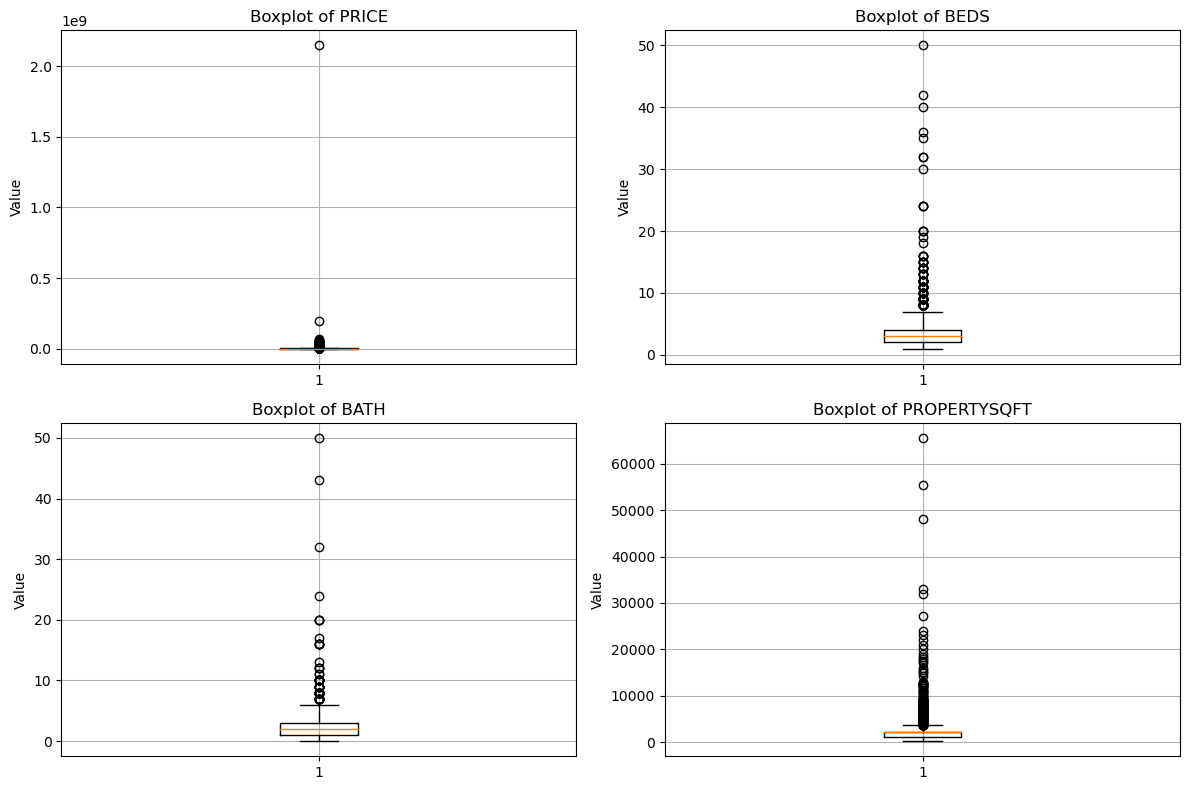

In [7]:
# Plot columns PRICE,BEDS,BATH,and PROPERTYSQFT with boxplot to visualize outliers.  
# Select relevant numeric columns
cols_to_plot = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']

# Create 4 subplots (1 row, 4 columns or 2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Loop through selected columns and plot boxplots
for i, col in enumerate(cols_to_plot):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()              

In [8]:
# Implementing capping to handle outliers.
def cap_outliers_iqr(df, columns):
    """
    Caps outliers in specified columns using IQR method.
    Returns a modified DataFrame and a dictionary of capped columns.
    """
    capped_df = df.copy()
    capped_info = {}

    for col in columns:
        Q1 = capped_df[col].quantile(0.25)
        Q3 = capped_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Store original outlier count
        outliers = ((capped_df[col] < lower) | (capped_df[col] > upper)).sum()
        capped_info[col] = outliers

        # Cap values
        capped_df[col] = capped_df[col].clip(lower=lower, upper=upper)

    return capped_df, capped_info

columns_to_cap = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT']
df_capped, capped_summary = cap_outliers_iqr(df, columns_to_cap)

print("Outliers capped per column:")
for col, count in capped_summary.items():
    print(f"{col}: {count} values capped")

Outliers capped per column:
PRICE: 528 values capped
BEDS: 218 values capped
BATH: 108 values capped
PROPERTYSQFT: 374 values capped


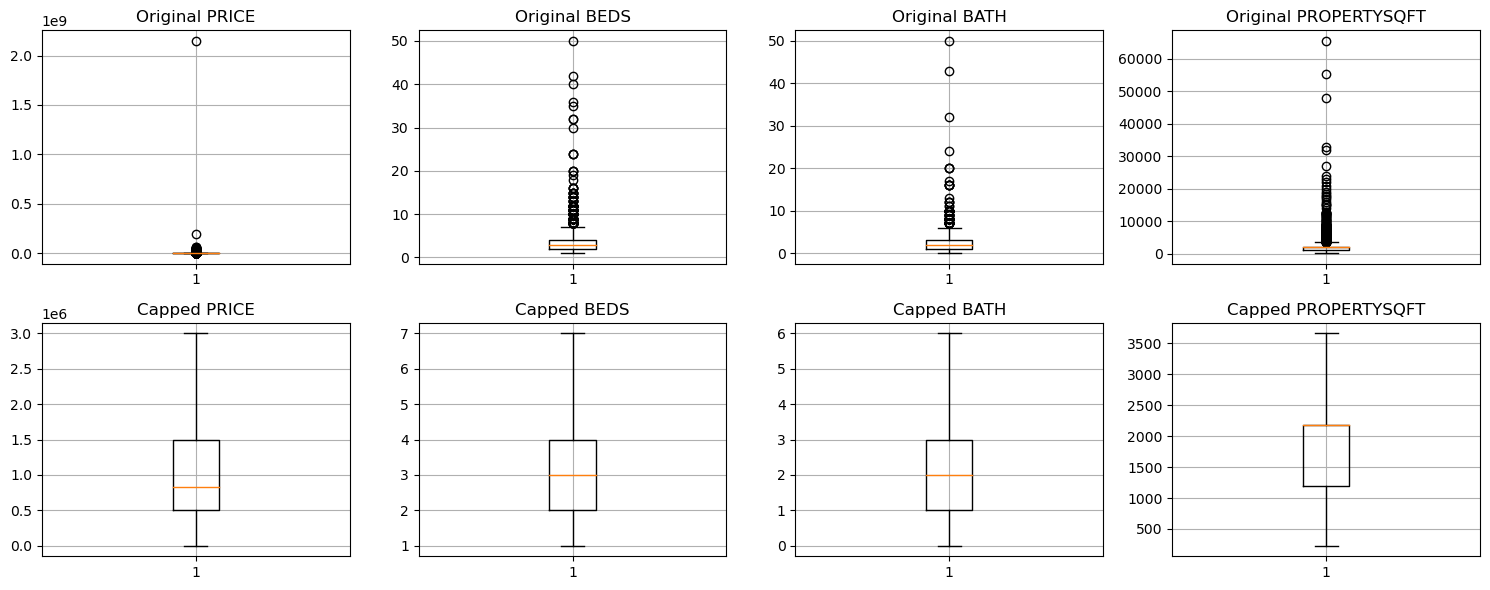

In [9]:
# Utilized boxplot to detect and foresee outliers.
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(columns_to_cap):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Original {col}')
    axes[i].grid(True)
    axes[i+4].boxplot(df_capped[col])
    axes[i+4].set_title(f'Capped {col}')
    axes[i+4].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Dataframe columns datatypes overview.
df_capped.dtypes

BROKERTITLE                     object
TYPE                            object
PRICE                            int64
BEDS                             int64
BATH                           float64
PROPERTYSQFT                   float64
ADDRESS                         object
STATE                           object
MAIN_ADDRESS                    object
ADMINISTRATIVE_AREA_LEVEL_2     object
LOCALITY                        object
SUBLOCALITY                     object
STREET_NAME                     object
LONG_NAME                       object
FORMATTED_ADDRESS               object
LATITUDE                       float64
LONGITUDE                      float64
dtype: object

In [11]:
#s Statistic Overview.
stat_overview = df_capped.describe()
stat_overview

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.587000e+03,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000
mean,1.144500e+06,3.166994,2.278106,1925.962121,40.713932,-73.941584
std,8.865572e+05,1.700804,1.335506,849.600409,0.087738,0.101276
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.638588,-73.987420
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726667,-73.949116
75%,1.498500e+06,4.000000,3.000000,2184.207862,40.771913,-73.869455
max,2.997750e+06,7.000000,6.000000,3660.519655,40.912729,-73.702450


## Section A. EDA(Explanatory Data Analysis)


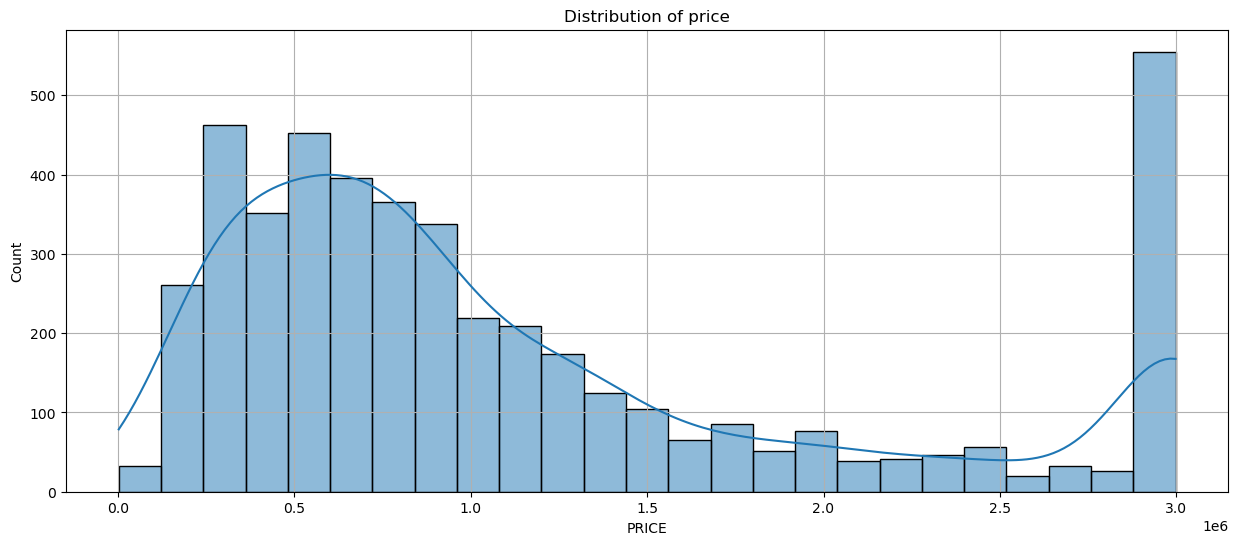

In [12]:
## What is the distribution of price.
plt.figure(figsize=(15,6))
sns.histplot(df_capped,x=df_capped['PRICE'],kde=True)
plt.title("Distribution of price")
plt.grid(True)
plt.show()

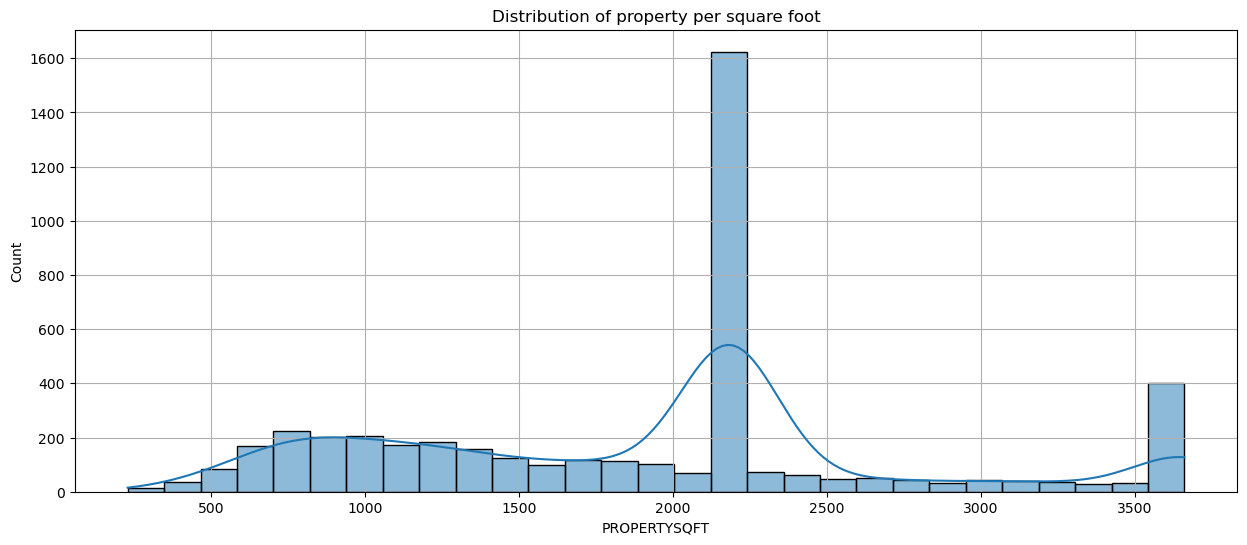

In [13]:
# Distribution of property per square foot.
plt.figure(figsize=(15,6))
sns.histplot(df_capped,x='PROPERTYSQFT',kde=True)
plt.title("Distribution of property per square foot")
plt.grid(True)
plt.show()

In [14]:
# Created a new column price/per/squarefoot.
df_capped['PRICE_PER_SQFT'] = df_capped['PRICE'] / df_capped['PROPERTYSQFT']
df_capped['PRICE_PER_SQFT']

0       225.000000
1       818.941102
2       129.032258
3       155.056180
4       818.941102
           ...    
4796    274.241298
4797    112.168812
4798    583.735652
4799    913.167939
4800    465.333333
Name: PRICE_PER_SQFT, Length: 4587, dtype: float64

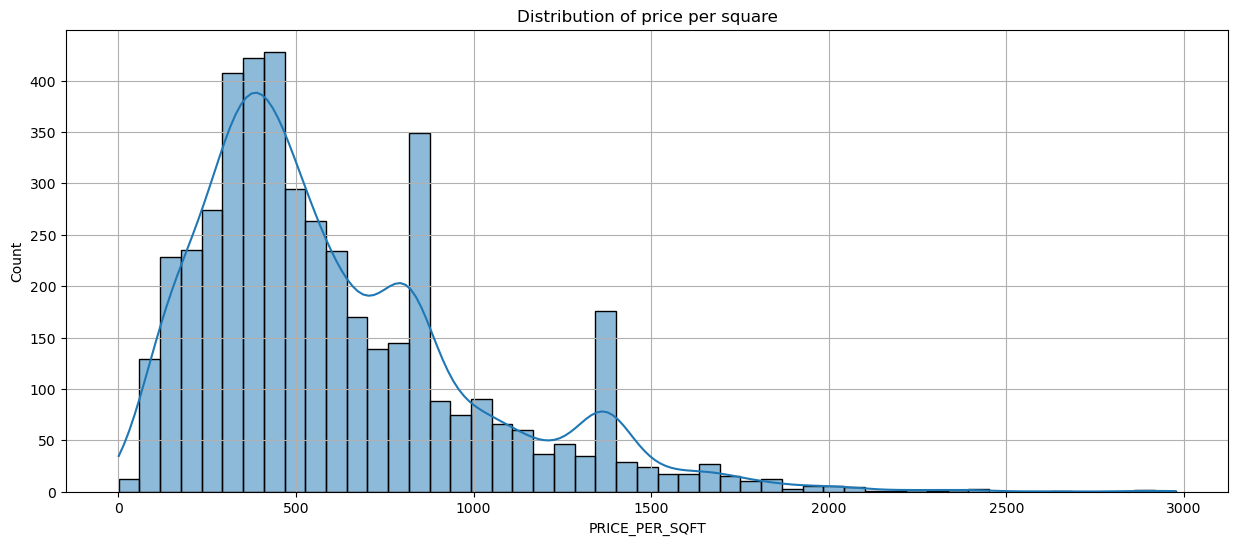

In [15]:
plt.figure(figsize=(15,6))
sns.histplot(df_capped,x = df_capped['PRICE_PER_SQFT'],kde=True)
plt.title("Distribution of price per square")
plt.grid(True)
plt.show()

In [16]:
# Hightlight only numeric important colums out.
numeric_cols = ['PRICE','PROPERTYSQFT','BEDS','BATH','PRICE_PER_SQFT']
numeric_cols 

['PRICE', 'PROPERTYSQFT', 'BEDS', 'BATH', 'PRICE_PER_SQFT']

## 1. Build a summary table combining location(mean,median,mode,std,range,and variance)

In [17]:
data_location_spread =  pd.DataFrame({
    'mean': df_capped[numeric_cols].mean(), # average value per column
    'median': df_capped[numeric_cols].median(), # middle value when sorted
    'mode': df_capped[numeric_cols].mode().iloc[0], # most frequently occurring value
    'std': df_capped[numeric_cols].std(), # square root of variance, same units as original data
    'range': df_capped[numeric_cols].max() - df_capped[numeric_cols].min(), # spread between max and min
    'variance': df_capped[numeric_cols].var() # # average squared deviation from the mean
})

# summary overview of how data are spread out in two significant figure.
data_location_spread.round(2)

,mean,median,mode,std,range,variance
PRICE,1144499.90,825000.00,2997750.00,886557.16,2995256.00,7.859836e+11
PROPERTYSQFT,1925.96,2184.21,2184.21,849.60,3430.52,7.218209e+05
BEDS,3.17,3.00,3.00,1.70,6.00,2.890000e+00
BATH,2.28,2.00,2.00,1.34,6.00,1.780000e+00
PRICE_PER_SQFT,607.87,500.84,818.94,393.21,2975.05,1.546126e+05


## 2. Distribution Shape / Skewness

In [18]:
# Calculate skewness on the capped (cleaned) data
skewness_capped = df_capped[numeric_cols].skew()

In [19]:
# Calculate skewness on the original (uncapped) data for comparison
skewness_raw = df[['PRICE','PROPERTYSQFT','BEDS','BATH']].skew()

In [20]:
# Print both side by side to show how much capping reduced skew
print("Skewness after capping:\n", skewness_capped.round(2))
print("\nSkewness before capping (raw):\n", skewness_raw.round(2))

Skewness after capping:
 PRICE             1.06
PROPERTYSQFT      0.33
BEDS              0.74
BATH              1.27
PRICE_PER_SQFT    1.29
dtype: float64

Skewness before capping (raw):
 PRICE           65.35
PROPERTYSQFT    12.35
BEDS             5.50
BATH             7.83
dtype: float64


IndexError: index 4 is out of bounds for axis 0 with size 4

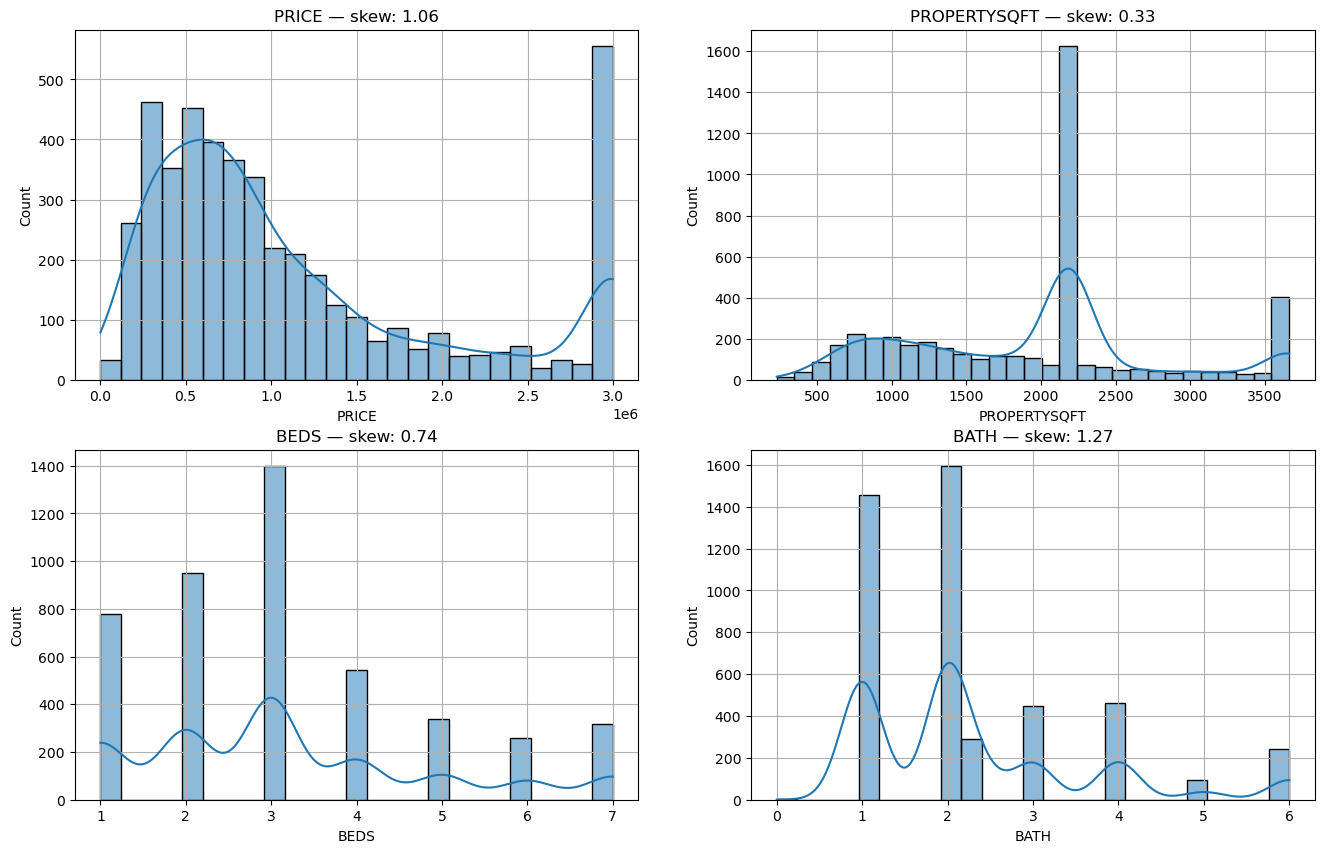

In [21]:
# Visualize distribution shape with histogram + KDE overlay for each variable
fig, axes = plt.subplots(2, 2, figsize=(16, 10))  # 2x2 grid of subplots
axes = axes.flatten()  # flatten grid into a simple list for looping

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_capped, x=col, kde=True, ax=axes[i])  # histogram with density curve
    axes[i].set_title(f'{col} — skew: {df_capped[col].skew():.2f}')  # show skew value in title
    axes[i].grid(True)
plt.tight_layout()
plt.show() 

## 3. Covariance Analysis

In [22]:
# Covariance insight
cov_matrix = df_capped[numeric_cols].cov()

# Round up to 2 significant figure.
cov_matrix.round(2)
# Note: PRI

,PRICE,PROPERTYSQFT,BEDS,BATH,PRICE_PER_SQFT
PRICE,7.859836e+11,4.324121e+08,699313.26,745471.11,2.482244e+08
PROPERTYSQFT,4.324121e+08,7.218209e+05,852.54,694.97,-2.624723e+04
BEDS,6.993133e+05,8.525400e+02,2.89,1.67,6.243000e+01
BATH,7.454711e+05,6.949700e+02,1.67,1.78,1.338100e+02
PRICE_PER_SQFT,2.482244e+08,-2.624723e+04,62.43,133.81,1.546126e+05


## 4. Correlation Analysis

In [23]:
# Correlation insight.
Corr_matrix = df_capped[numeric_cols].corr() 

# Round up to 2 significant figure.
Corr_matrix.round(2)

,PRICE,PROPERTYSQFT,BEDS,BATH,PRICE_PER_SQFT
PRICE,1.00,0.57,0.46,0.63,0.71
PROPERTYSQFT,0.57,1.00,0.59,0.61,-0.08
BEDS,0.46,0.59,1.00,0.74,0.09
BATH,0.63,0.61,0.74,1.00,0.25
PRICE_PER_SQFT,0.71,-0.08,0.09,0.25,1.00


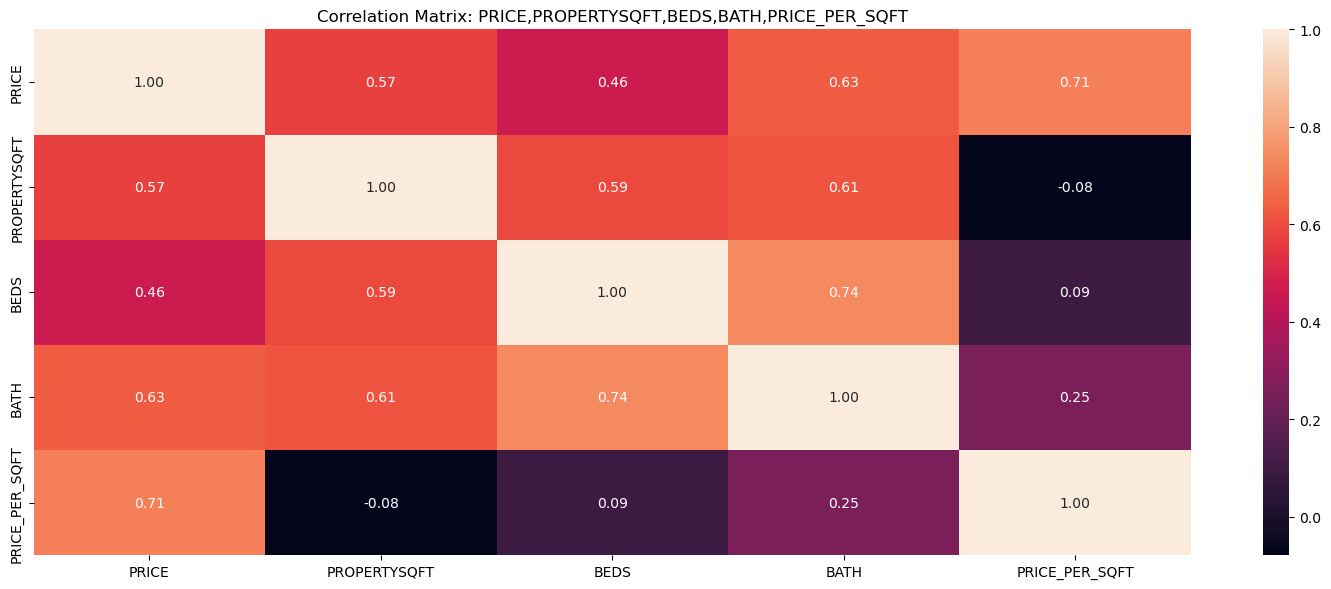

In [24]:
# Correlation Visualization 
plt.figure(figsize=(15,6))
sns.heatmap(Corr_matrix,fmt='.2f',annot = True)
plt.title('Correlation Matrix: PRICE,PROPERTYSQFT,BEDS,BATH,PRICE_PER_SQFT')
plt.tight_layout()
plt.show()

## 5. Iterative deepeer exploration

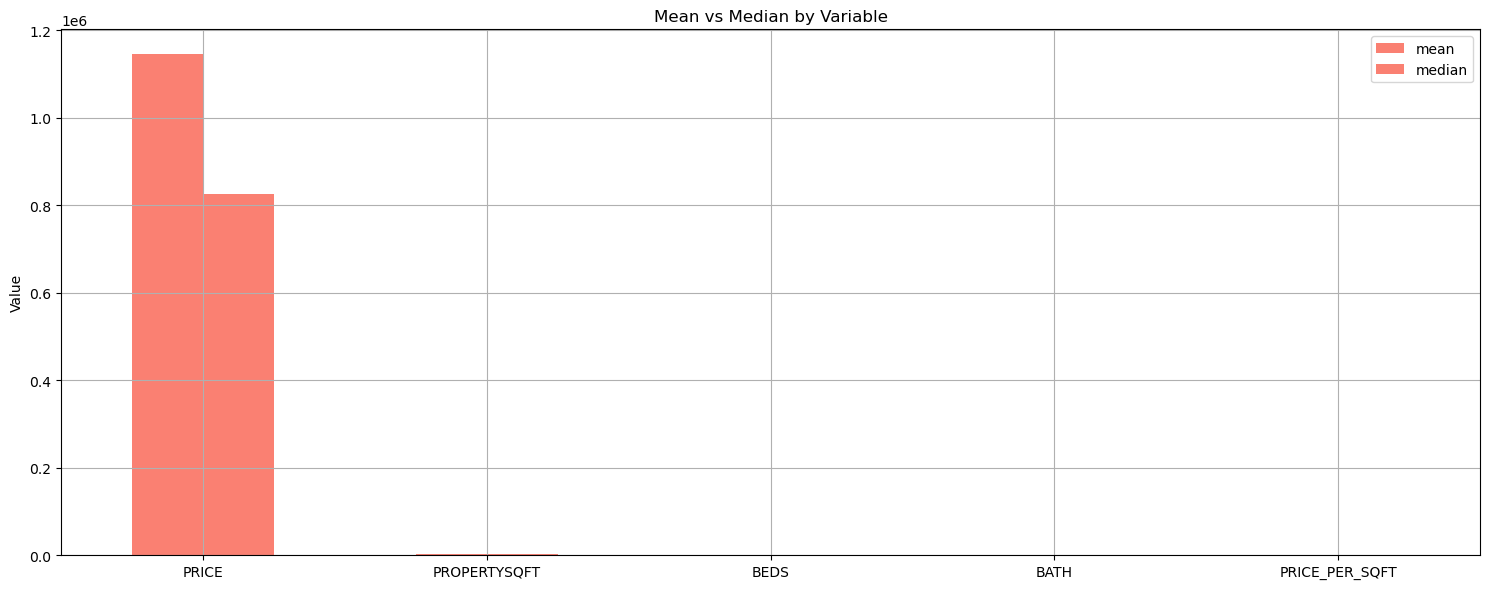

In [25]:
# Mean vs median bar chart — visualizes skew by showing the gap between the two
data_location_spread[['mean', 'median']].plot(kind='bar', figsize=(15, 6), color = 'salmon')
plt.title('Mean vs Median by Variable')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(True)
plt.show()

C:\Users\LUPHEN\AnacondaFile\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1500x600 with 0 Axes>

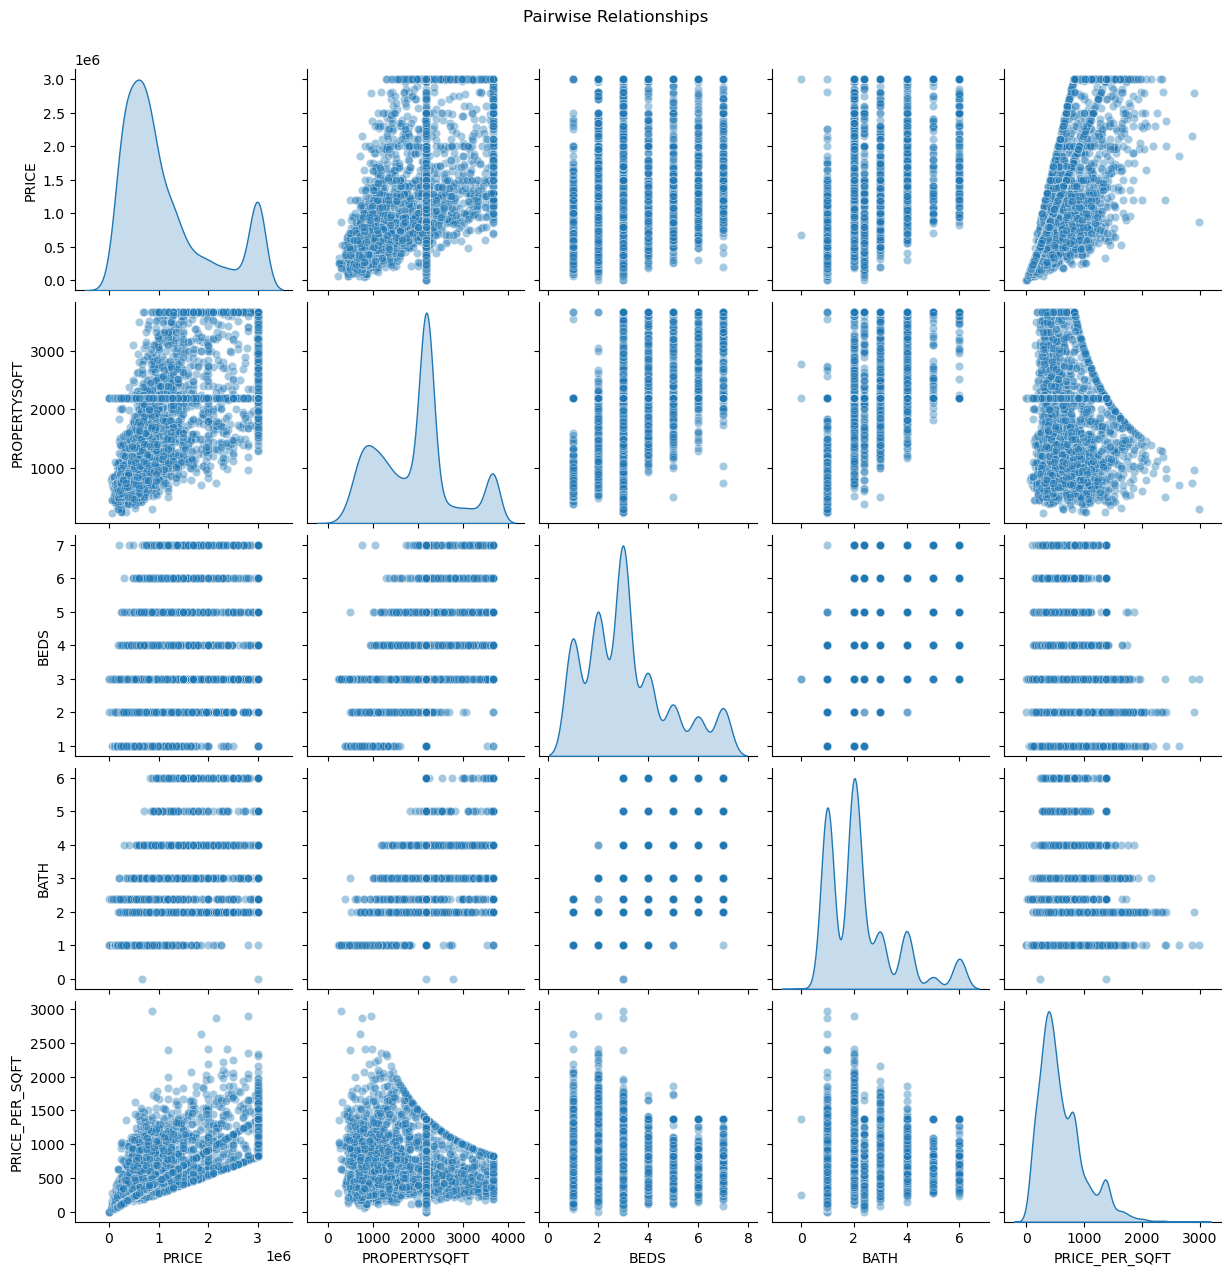

In [26]:
# Pairwise scatter + density plots for all four numeric variables at once
plt.figure(figsize=(15,6))
sns.pairplot(df_capped[numeric_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

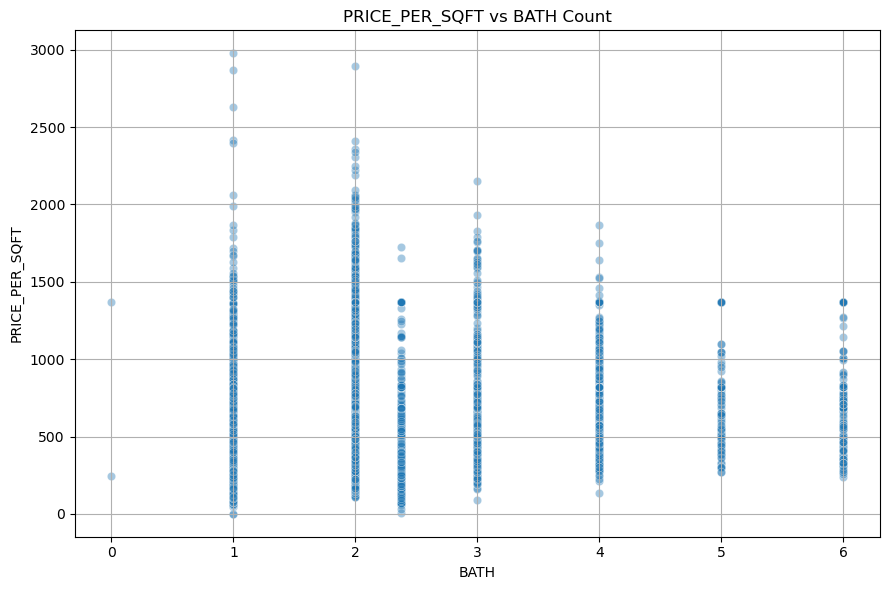

In [27]:
 # Scatter plot to visually confirm the PRICE_PER_SQFT-BATH correlation found above
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_capped, x='BATH', y='PRICE_PER_SQFT', alpha=0.4)
plt.title('PRICE_PER_SQFT vs BATH Count')
plt.tight_layout()
plt.grid(True)
plt.show()

## section B. Explanatory data analysis questions

### 1. What was the distribution of house type?

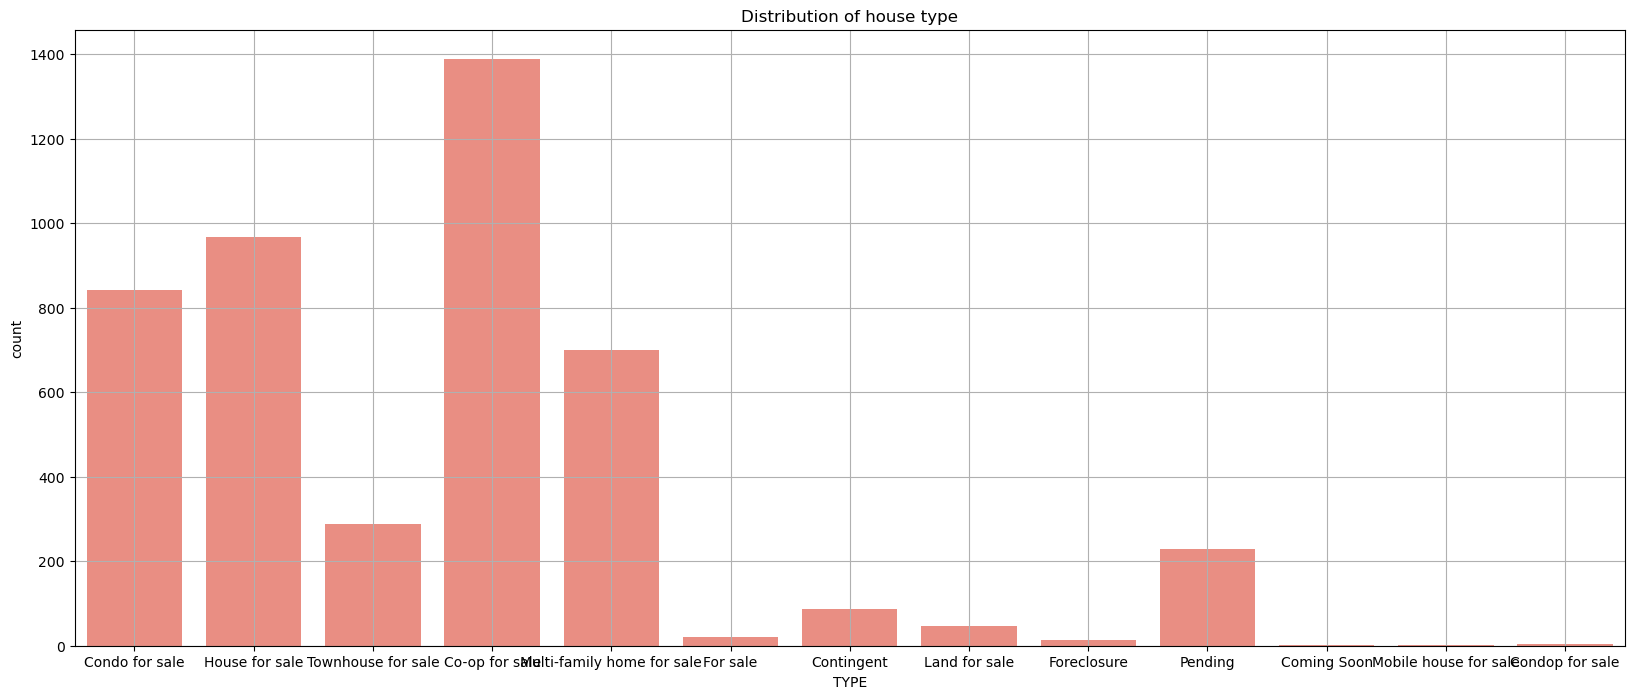

In [28]:
plt.figure(figsize=(20,8))
sns.countplot(df_capped,x = df_capped['TYPE'], color = 'salmon')
plt.title("Distribution of house type")
plt.grid(True)
plt.show()

### 2. What was the distribution of bathroom?

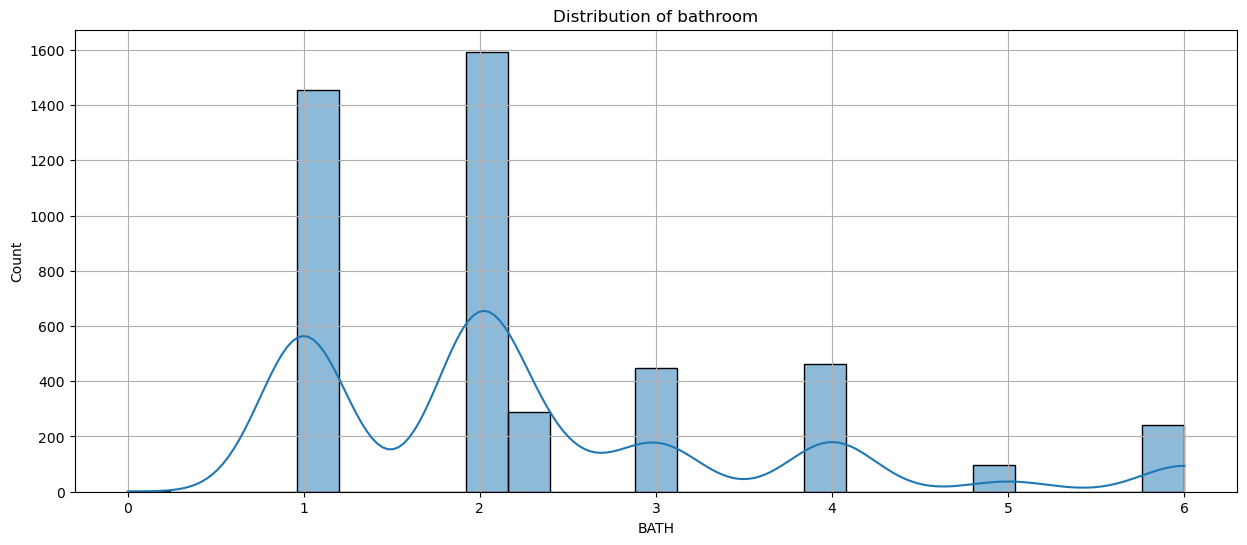

In [29]:
plt.figure(figsize=(15,6))
sns.histplot(df_capped,x = df_capped['BATH'],kde=True)
plt.title("Distribution of bathroom")
plt.grid(True)
plt.show()

### 3. What was the distribution of bed space?

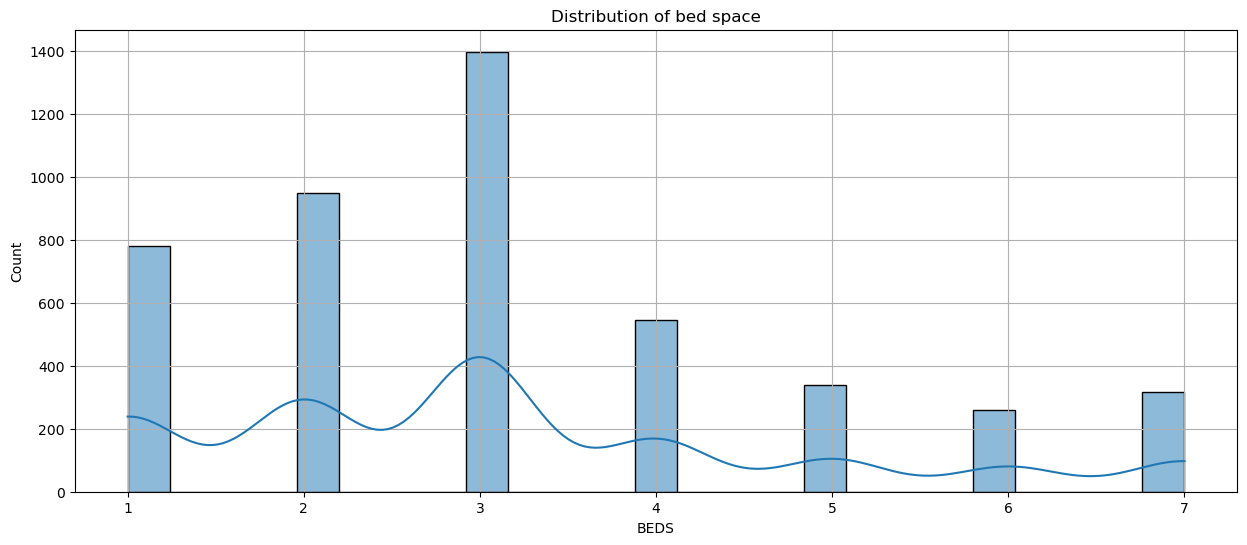

In [30]:
plt.figure(figsize=(15,6))
sns.histplot(df_capped,x = df_capped['BEDS'],kde=True)
plt.title("Distribution of bed space")
plt.grid(True)
plt.show()

### 4. What was the price per square foot by sublocality?

In [31]:
locality_median_price = df_capped.groupby(['SUBLOCALITY'])['PRICE_PER_SQFT'].median().sort_values(
    ascending= False).reset_index()
locality_median_price
# Top ten locality by price per square foot.
top_ten_sublocality = locality_median_price.nlargest(10,'PRICE_PER_SQFT')
top_ten_sublocality

,SUBLOCALITY,PRICE_PER_SQFT
0,Manhattan,1220.582248
1,Dumbo,1200.540649
2,Brooklyn Heights,958.588957
3,New York,818.941102
4,New York County,818.941102
5,Fort Hamilton,767.948718
6,Coney Island,670.312500
7,Snyder Avenue,619.047619
8,Kings County,608.572890
9,Brooklyn,531.555556


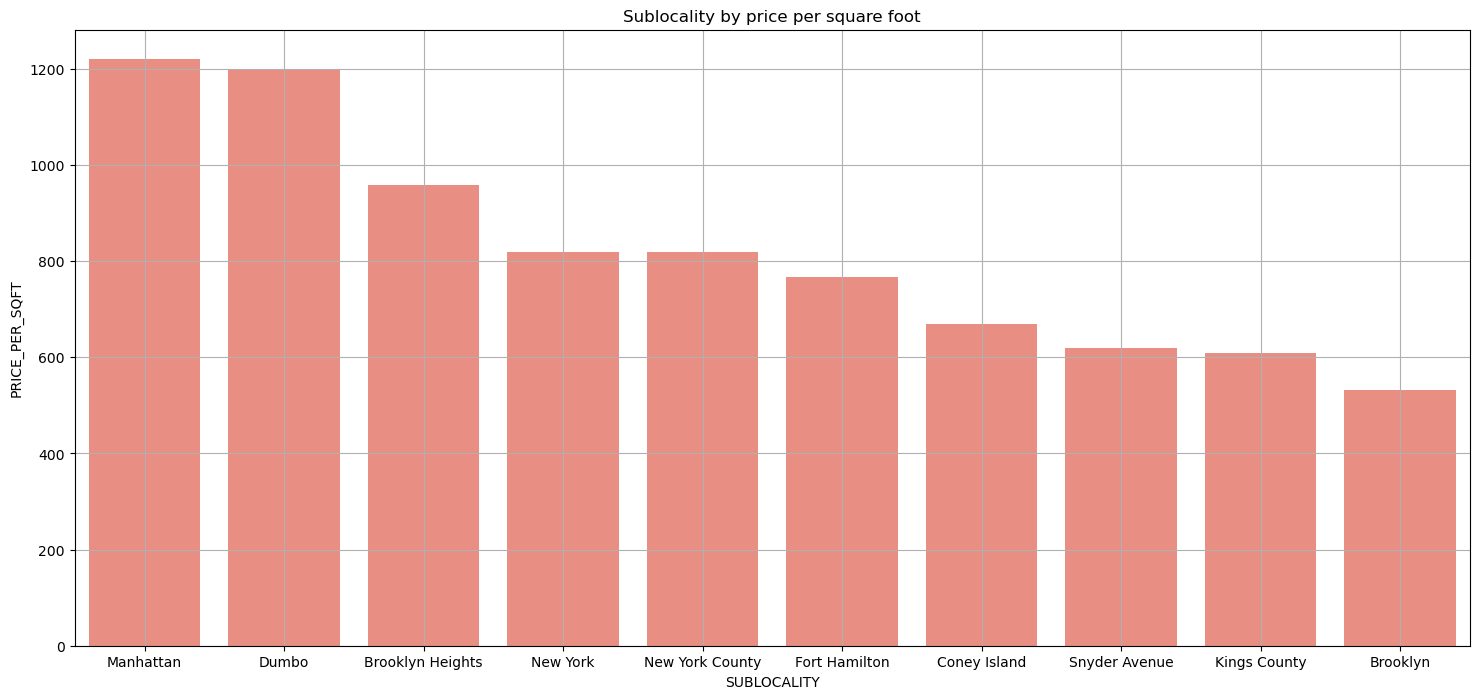

In [32]:
plt.figure(figsize=(18,8))
sns.barplot(top_ten_sublocality,x = top_ten_sublocality['SUBLOCALITY'], y =top_ten_sublocality['PRICE_PER_SQFT'],color='salmon')
plt.title("Sublocality by price per square foot")
plt.grid(True)
plt.show()